# Гипотеза: Рост зарплаты от стажа зависит от специализации

Этот ноутбук проверяет гипотезу:

**Чем больше опыт работы, тем выше ожидаемая зарплата, но форма и сила этой зависимости различаются между специальностями.**

Для проверки используются очищенные данные из `dataset_cleaned.csv`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Загрузка очищенных данных

In [2]:
df = pd.read_csv("dataset_cleaned.csv")

if "date_publish" in df.columns:
    df["date_publish"] = pd.to_datetime(df["date_publish"], errors="coerce")

df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df["experience"] = pd.to_numeric(df["experience"], errors="coerce")
df["position_name"] = df["position_name"].fillna("Не указано")

print(df.shape)
df[["position_name", "salary", "experience"]].head()

(43227, 65)


,position_name,salary,experience
0,Оператор,20000,17.0
1,Продавец,20000,0.0
2,Бухгалтер,25000,12.0
3,Водитель погрузчика,30000,0.0
4,Водитель категории в с,35000,3.0


## 2. Рабочая выборка для гипотезы

In [3]:
hyp_df = df[["position_name", "salary", "experience"]].dropna().copy()
hyp_df = hyp_df[(hyp_df["salary"] > 0) & (hyp_df["experience"] >= 0)].copy()

position_counts = hyp_df["position_name"].value_counts()
top_positions = position_counts.head(12).index.tolist()

hyp_df_top = hyp_df[hyp_df["position_name"].isin(top_positions)].copy()

summary = pd.DataFrame({
    "count": hyp_df_top.groupby("position_name").size(),
    "mean_salary": hyp_df_top.groupby("position_name")["salary"].mean(),
    "median_salary": hyp_df_top.groupby("position_name")["salary"].median(),
    "mean_experience": hyp_df_top.groupby("position_name")["experience"].mean(),
}).sort_values("count", ascending=False)
summary.round(2)

,count,mean_salary,median_salary,mean_experience
position_name,,,,
Бухгалтер,2109,24447.50,20000.0,7.74
Специалист,2072,23174.00,20000.0,6.25
Администратор,1196,23515.84,20000.0,5.02
Менеджер,1143,25242.40,20000.0,5.97
Экономист,919,26317.19,25000.0,6.61
Инженер,565,30555.75,26000.0,6.61
Продавец,555,19835.82,18000.0,2.79
Секретарь,543,20755.06,20000.0,4.45
Делопроизводитель,518,20831.39,20000.0,5.66


## 3. Общая зависимость зарплаты от стажа

In [4]:
experience_curve = hyp_df.groupby("experience").agg(
    mean_salary=("salary", "mean"),
    median_salary=("salary", "median"),
    count=("salary", "size"),
).reset_index()

experience_curve = experience_curve[experience_curve["count"] >= 30]
experience_curve.head()

,experience,mean_salary,median_salary,count
0,0.0,23021.032412,20000.0,14223
1,1.0,22894.700611,20000.0,4252
2,2.0,23500.986928,20000.0,2754
3,3.0,24801.122501,20000.0,2351
4,4.0,24749.588977,20000.0,2141


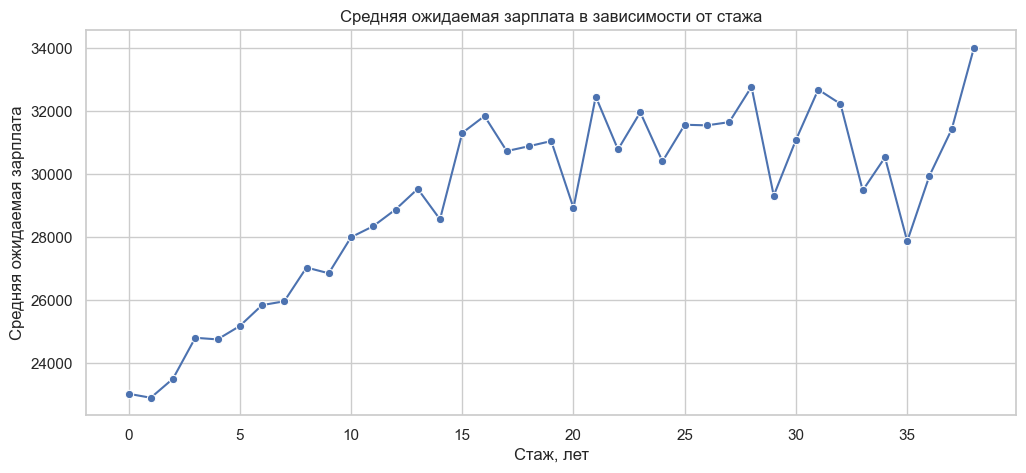

In [5]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=experience_curve, x="experience", y="mean_salary", marker="o")
plt.title("Средняя ожидаемая зарплата в зависимости от стажа")
plt.xlabel("Стаж, лет")
plt.ylabel("Средняя ожидаемая зарплата")
plt.show()

## 4. Средняя зарплата по бакетам стажа и специальностям

In [6]:
hyp_df_top["experience_bucket"] = pd.cut(
    hyp_df_top["experience"],
    bins=[-0.1, 0, 1, 3, 5, 10, 20, 60, 1000],
    labels=["0", "1", "2-3", "4-5", "6-10", "11-20", "21-60", "61+"],
)

bucket_specialty = hyp_df_top.groupby(["position_name", "experience_bucket"]).agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()

bucket_specialty = bucket_specialty[bucket_specialty["count"] >= 10]
bucket_specialty.head(20)

,position_name,experience_bucket,mean_salary,count
0,Администратор,0,22975.283920,398
1,Администратор,1,23088.533333,150
2,Администратор,2-3,23338.837209,172
3,Администратор,4-5,23640.350877,114
4,Администратор,6-10,23231.494253,174
5,Администратор,11-20,24831.355932,118
6,Администратор,21-60,26226.257143,70
7,Бухгалтер,0,22270.935961,406
8,Бухгалтер,1,21136.417910,134
9,Бухгалтер,2-3,23407.060302,199


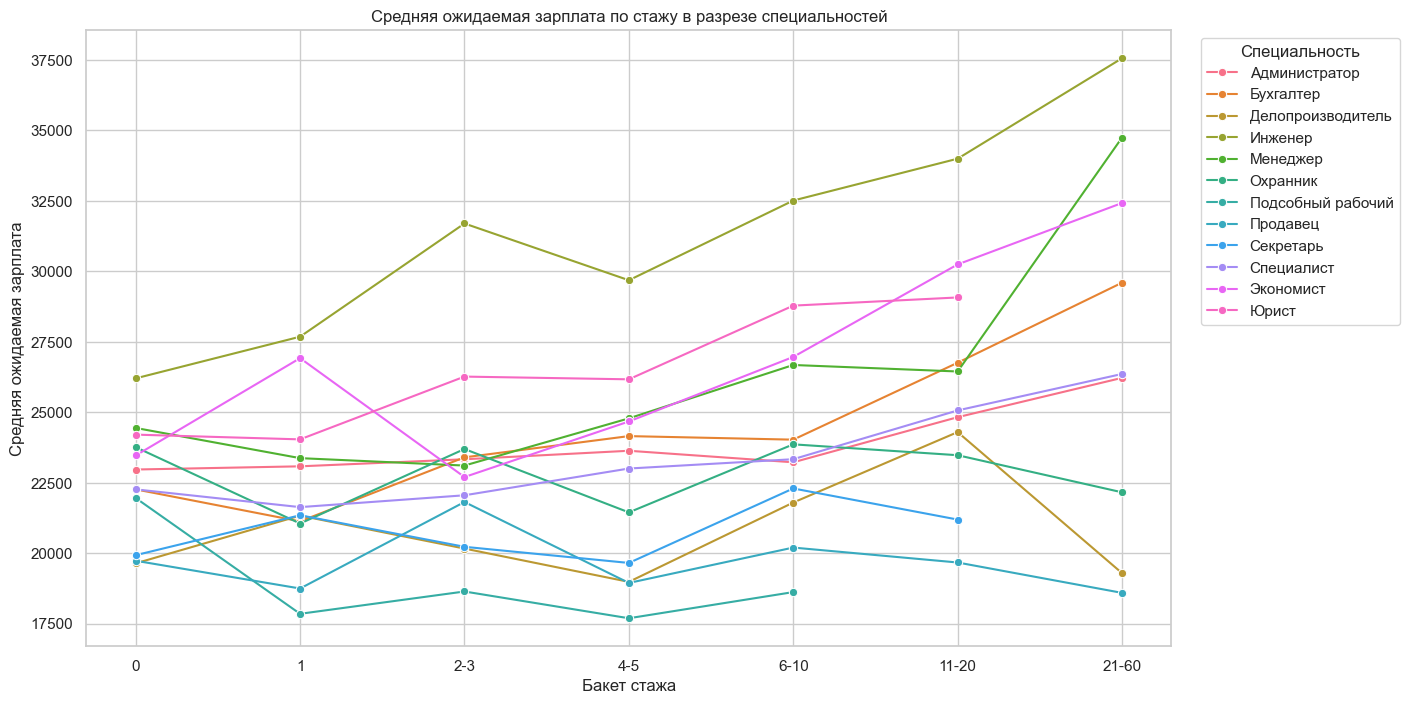

In [7]:
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=bucket_specialty,
    x="experience_bucket",
    y="mean_salary",
    hue="position_name",
    marker="o",
)
plt.title("Средняя ожидаемая зарплата по стажу в разрезе специальностей")
plt.xlabel("Бакет стажа")
plt.ylabel("Средняя ожидаемая зарплата")
plt.legend(title="Специальность", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 5. Матрица графиков: зарплата от стажа по специальностям

In [8]:
specialty_curve = hyp_df_top.groupby(["position_name", "experience"]).agg(
    mean_salary=("salary", "mean"),
    count=("salary", "size"),
).reset_index()

specialty_curve = specialty_curve[specialty_curve["count"] >= 10]
specialty_curve.head(20)

,position_name,experience,mean_salary,count
0,Администратор,0.0,22975.283920,398
1,Администратор,1.0,23088.533333,150
2,Администратор,2.0,23654.831461,89
3,Администратор,3.0,23000.000000,83
4,Администратор,4.0,22876.923077,65
5,Администратор,5.0,24653.061224,49
6,Администратор,6.0,21395.833333,48
7,Администратор,7.0,24621.621622,37
8,Администратор,8.0,23665.000000,32
9,Администратор,9.0,22685.714286,35


Text(0.5, 0.98, 'Зависимость средней ожидаемой зарплаты от стажа по специальностям')

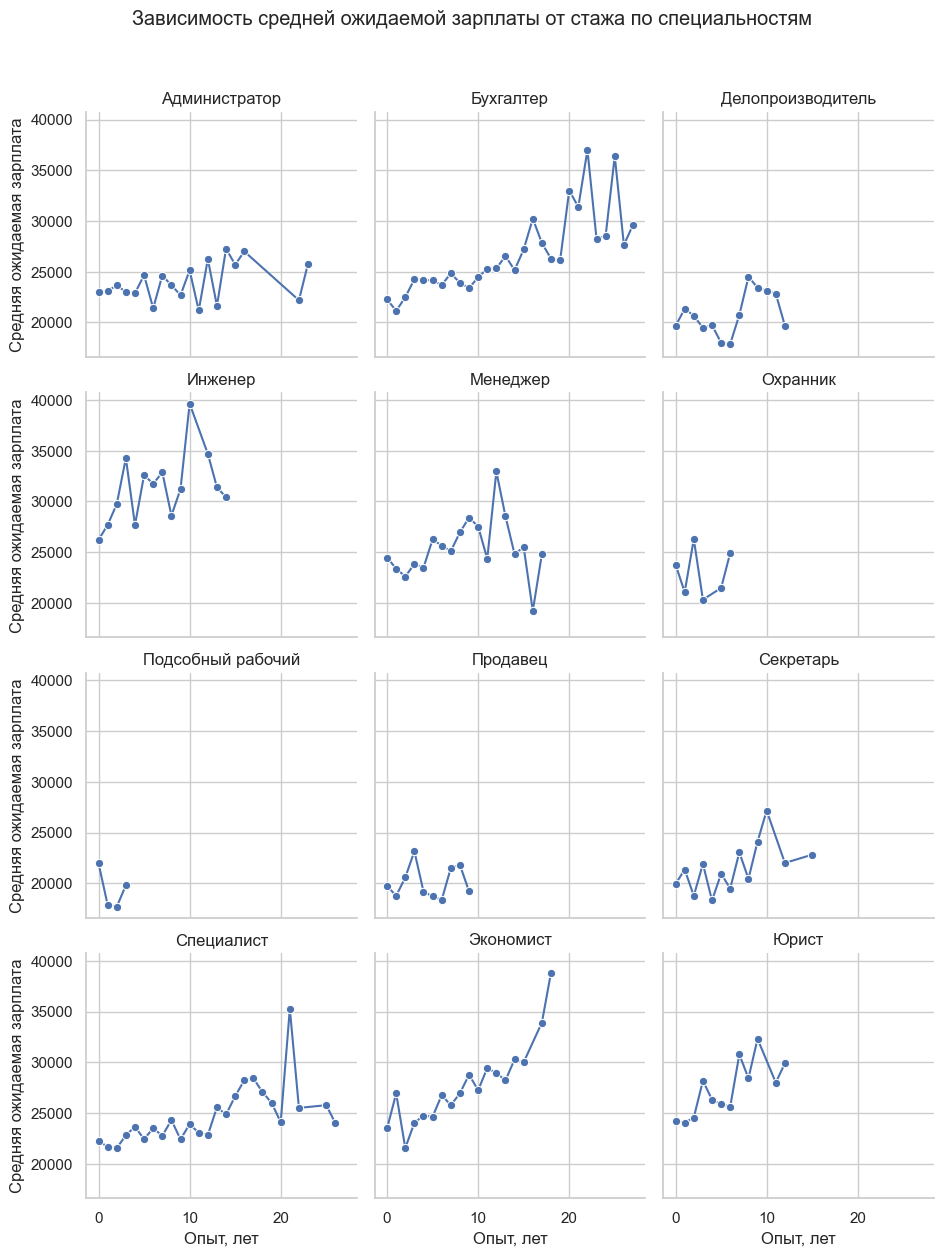

In [9]:
g = sns.FacetGrid(
    specialty_curve,
    col="position_name",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=3.2,
)
g.map_dataframe(sns.lineplot, x="experience", y="mean_salary", marker="o")
g.set_axis_labels("Опыт, лет", "Средняя ожидаемая зарплата")
g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Зависимость средней ожидаемой зарплаты от стажа по специальностям")

## 6. Тепловая карта: средняя зарплата по специальностям и стажу

In [10]:
heatmap_df = bucket_specialty.pivot(index="position_name", columns="experience_bucket", values="mean_salary")
heatmap_df = heatmap_df.reindex(index=top_positions)
heatmap_df.round(1)

experience_bucket,0,1,2-3,4-5,6-10,11-20,21-60
position_name,,,,,,,
Бухгалтер,22270.9,21136.4,23407.1,24160.3,24034.5,26763.3,29602.1
Специалист,22270.7,21641.5,22061.3,23010.9,23340.7,25071.4,26364.5
Администратор,22975.3,23088.5,23338.8,23640.4,23231.5,24831.4,26226.3
Менеджер,24449.4,23378.6,23115.9,24789.6,26682.9,26452.6,34750.0
Экономист,23473.0,26925.4,22708.3,24679.2,26968.6,30250.0,32428.6
Инженер,26208.9,27686.3,31701.5,29688.5,32515.2,34000.0,37562.5
Продавец,19739.2,18755.1,21823.5,18952.4,20206.9,19677.4,18600.0
Секретарь,19937.1,21352.9,20234.0,19661.8,22303.7,21200.0,NaN
Делопроизводитель,19647.1,21340.0,20171.9,18990.4,21804.1,24302.8,19300.0


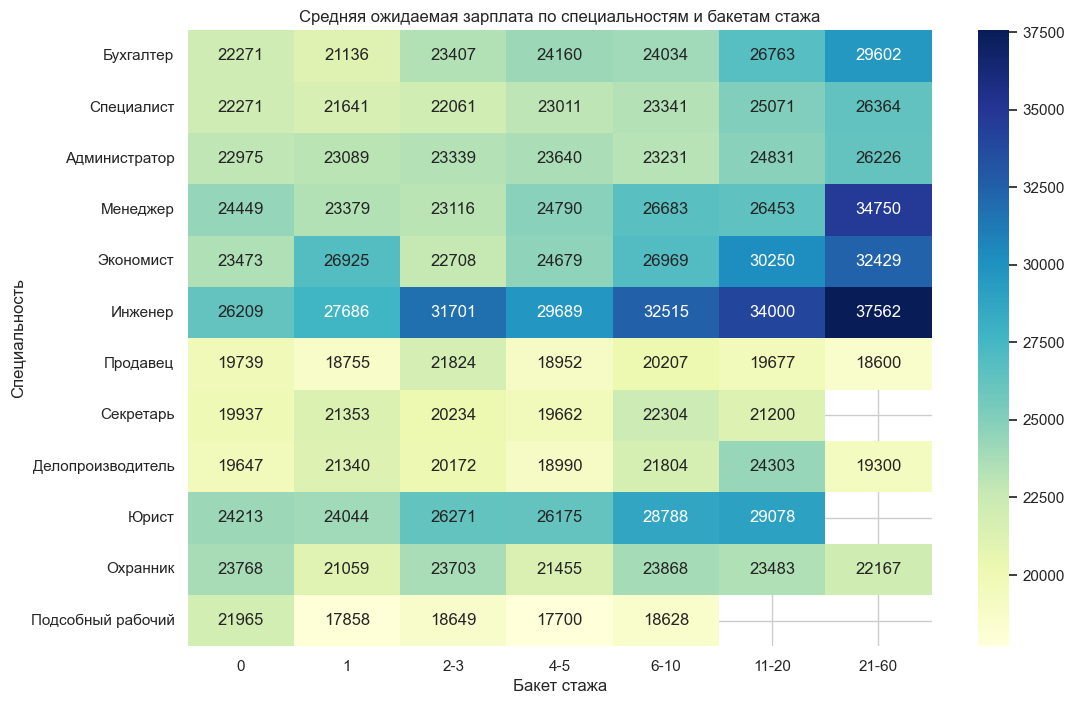

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Средняя ожидаемая зарплата по специальностям и бакетам стажа")
plt.xlabel("Бакет стажа")
plt.ylabel("Специальность")
plt.show()

## 7. Сила связи `зарплата ~ опыт` по специальностям

In [12]:
specialty_corr = (
    hyp_df_top.groupby("position_name")
    .apply(lambda x: x[["salary", "experience"]].corr(method="spearman").loc["salary", "experience"])
    .rename("spearman_salary_experience")
    .reset_index()
    .sort_values("spearman_salary_experience", ascending=False)
)

specialty_corr.round(3)

,position_name,spearman_salary_experience
3,Инженер,0.274
10,Экономист,0.263
1,Бухгалтер,0.231
11,Юрист,0.222
4,Менеджер,0.162
9,Специалист,0.134
2,Делопроизводитель,0.126
8,Секретарь,0.103
0,Администратор,0.065
5,Охранник,0.028


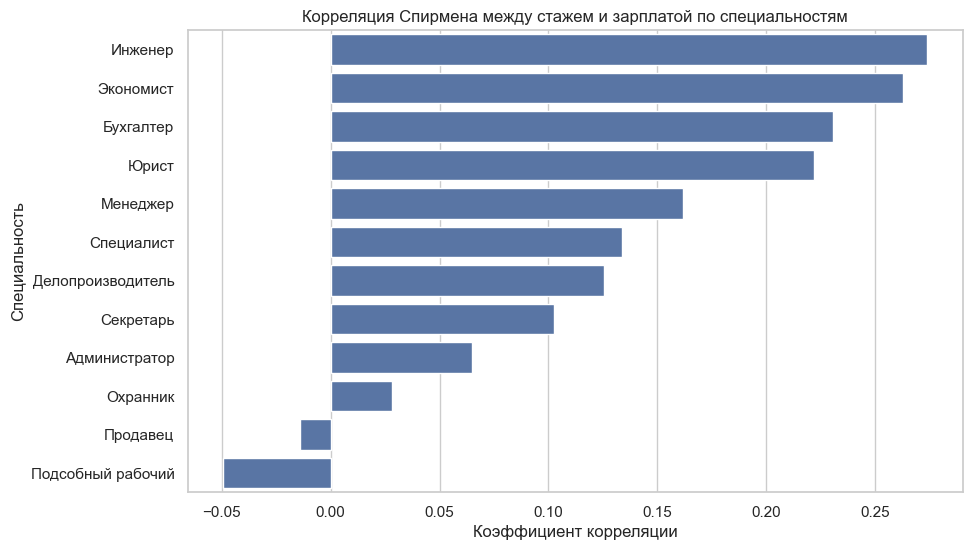

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=specialty_corr, x="spearman_salary_experience", y="position_name", color="#4C72B0")
plt.title("Корреляция Спирмена между стажем и зарплатой по специальностям")
plt.xlabel("Коэффициент корреляции")
plt.ylabel("Специальность")
plt.show()

## 8. Интерпретация гипотезы

Гипотеза подтверждается, если по графикам видно следующее:
- в среднем зарплата растёт с опытом;
- линии для разных специальностей заметно отличаются по наклону или форме;
- тепловая карта показывает неодинаковый рост по бакетам стажа;
- коэффициенты корреляции `salary ~ experience` различаются между специальностями.

Если в одних специальностях рост выражен сильно, а в других слабый или почти отсутствует, это и будет прямым подтверждением гипотезы, что зависимость зарплаты от стажа определяется специализацией.